# Detección de Código Generado por IA — SemEval-2026 Task 13 

**Equipo (EquipoCompiladores):** Juan Pablo Chávez Leal · Mauricio Anguiano Juárez · Daniel Contreras Chávez — ITESM, Campus Querétaro (TC3002B).

Clasificación binaria de fragmentos de código: humano vs generado por IA , replicando a Ramachandra et al. (2026).

In [ ]:
# ============================================================
# CELDA 1 - Instalacion e imports
# ============================================================
%pip install -q kagglehub xgboost scikit-learn pandas numpy pyarrow matplotlib

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports listos.')

In [2]:
# ============================================================
# CELDA 2 - Descarga del dataset SemEval-2026 Task 13 (Subtask A)
# ============================================================
# Requiere credenciales de Kaggle. Al ejecutar, kagglehub pedira
# tu usuario y key de Kaggle (o usa el token kaggle.json).
import kagglehub

# Descarga el dataset completo y devuelve la ruta local en cache
DATASET_PATH = kagglehub.dataset_download('daniilor/semeval-2026-task13')
print('Dataset descargado en:', DATASET_PATH)

Dataset descargado en: C:\Users\Mauricio\.cache\kagglehub\datasets\daniilor\semeval-2026-task13\versions\3


In [3]:
# ============================================================
# CELDA 3 - Carga del dataset SemEval (Subtask A = carpeta task_a)
# ============================================================
# Usamos los splits oficiales de la competencia: el archivo de
# entrenamiento para entrenar y el de validacion para evaluar.
all_parquets = glob.glob(os.path.join(DATASET_PATH, '**', '*.parquet'), recursive=True)
train_file = [p for p in all_parquets if 'task_a_training' in p.lower()][0]
val_file = [p for p in all_parquets if 'task_a_validation' in p.lower()][0]
print('Train:', train_file)
print('Val:  ', val_file)

def carga_split(path):
    d = pd.read_parquet(path)
    d = d.dropna(subset=['code', 'label']).reset_index(drop=True)
    d['label'] = d['label'].astype(int)
    return d

df_tr = carga_split(train_file)
df_val = carga_split(val_file)

codes_tr = df_tr['code'].astype(str).tolist()
y_tr = df_tr['label'].values
codes_val = df_val['code'].astype(str).tolist()
y_val = df_val['label'].values

print(f'\nTrain: {len(y_tr)} filas | 0 (humano): {(y_tr==0).sum()} | 1 (maquina): {(y_tr==1).sum()}')
print(f'Val:   {len(y_val)} filas | 0 (humano): {(y_val==0).sum()} | 1 (maquina): {(y_val==1).sum()}')
df_tr.head(3)

Train: C:\Users\Mauricio\.cache\kagglehub\datasets\daniilor\semeval-2026-task13\versions\3\SemEval-2026-Task13\task_a\task_a_training_set_1.parquet
Val:   C:\Users\Mauricio\.cache\kagglehub\datasets\daniilor\semeval-2026-task13\versions\3\SemEval-2026-Task13\task_a\task_a_validation_set.parquet

Train: 500000 filas | 0 (humano): 238475 | 1 (maquina): 261525
Val:   100000 filas | 0 (humano): 47695 | 1 (maquina): 52305


,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python


## Enfoque principal — Features + TF-IDF + Random Forest / XGBoost

(La explicación completa de la metodología está en `Marco de referencia.md`.)

In [4]:
# ============================================================
# CELDA 4 - Features estructurales del codigo + TF-IDF
# ============================================================
def code_features(src):
    lines = src.split('\n')
    n_lines = len(lines)
    n_chars = len(src)
    n_blank = sum(1 for ln in lines if ln.strip() == '')
    n_comment = sum(1 for ln in lines if ln.strip().startswith(('#', '//', '/*', '*')))
    indents = [len(ln) - len(ln.lstrip(' ')) for ln in lines if ln.strip()]
    avg_indent = (sum(indents) / len(indents)) if indents else 0.0
    avg_line_len = (sum(len(ln) for ln in lines) / n_lines) if n_lines else 0.0
    n_space = src.count(' ')
    n_tab = src.count('\t')
    ratio_ws = ((n_space + n_tab) / n_chars) if n_chars else 0.0
    ratio_comment = (n_comment / n_lines) if n_lines else 0.0
    ratio_blank = (n_blank / n_lines) if n_lines else 0.0
    return [n_lines, n_chars, n_blank, n_comment, avg_indent, avg_line_len, n_space, n_tab, ratio_ws, ratio_comment, ratio_blank]

FEATURE_NAMES = ['n_lines','n_chars','n_blank','n_comment','avg_indent','avg_line_len','n_space','n_tab','ratio_ws','ratio_comment','ratio_blank']

X_feat_tr = np.array([code_features(c) for c in codes_tr], dtype='float32')
X_feat_val = np.array([code_features(c) for c in codes_val], dtype='float32')
print('Features train:', X_feat_tr.shape, '| val:', X_feat_val.shape)

# TF-IDF sobre tokens del codigo (preserva mayusculas e identificadores).
# Importante: tfidf y scaler se ajustan SOLO con el train, para no
# filtrar informacion del conjunto de validacion.
tfidf = TfidfVectorizer(lowercase=False, token_pattern=r'[A-Za-z_][A-Za-z0-9_]*|[^\sA-Za-z0-9_]', ngram_range=(1, 2), max_features=20000, min_df=2)
X_tfidf_tr = tfidf.fit_transform(codes_tr)
X_tfidf_val = tfidf.transform(codes_val)
print('TF-IDF train:', X_tfidf_tr.shape, '| val:', X_tfidf_val.shape)

# Concatena features tabulares (escaladas) + TF-IDF en una matriz sparse
scaler = StandardScaler()
X_tr = hstack([csr_matrix(scaler.fit_transform(X_feat_tr)), X_tfidf_tr]).tocsr()
X_val = hstack([csr_matrix(scaler.transform(X_feat_val)), X_tfidf_val]).tocsr()
print('Matriz combinada train:', X_tr.shape, '| val:', X_val.shape)

Features train: (500000, 11) | val: (100000, 11)
TF-IDF train: (500000, 20000) | val: (100000, 20000)
Matriz combinada train: (500000, 20011) | val: (100000, 20011)


In [5]:
# ============================================================
# CELDA 5 - Entrenamiento Random Forest y XGBoost (arquitectura del paper)
# ============================================================
results = {}

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, n_jobs=-1,
    class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_val)
rf_f1 = f1_score(y_val, rf_pred, average='macro')
results['RandomForest'] = rf_f1
print(f'Random Forest  -> macro F1 = {rf_f1:.4f}')
print(classification_report(y_val, rf_pred, digits=4))

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE)
xgb.fit(X_tr, y_tr)
xgb_pred = xgb.predict(X_val)
xgb_f1 = f1_score(y_val, xgb_pred, average='macro')
results['XGBoost'] = xgb_f1
print(f'\nXGBoost  -> macro F1 = {xgb_f1:.4f}')
print(classification_report(y_val, xgb_pred, digits=4))

Random Forest  -> macro F1 = 0.9832
              precision    recall  f1-score   support

           0     0.9867    0.9780    0.9823     47695
           1     0.9801    0.9880    0.9840     52305

    accuracy                         0.9832    100000
   macro avg     0.9834    0.9830    0.9832    100000
weighted avg     0.9832    0.9832    0.9832    100000


XGBoost  -> macro F1 = 0.9917
              precision    recall  f1-score   support

           0     0.9906    0.9921    0.9914     47695
           1     0.9928    0.9914    0.9921     52305

    accuracy                         0.9918    100000
   macro avg     0.9917    0.9918    0.9917    100000
weighted avg     0.9918    0.9918    0.9918    100000



   25 arboles | train logloss = 0.0801 | val logloss = 0.0832
   50 arboles | train logloss = 0.0373 | val logloss = 0.0420
   75 arboles | train logloss = 0.0315 | val logloss = 0.0368
  100 arboles | train logloss = 0.0274 | val logloss = 0.0334
  125 arboles | train logloss = 0.0249 | val logloss = 0.0316
  150 arboles | train logloss = 0.0231 | val logloss = 0.0303
  175 arboles | train logloss = 0.0213 | val logloss = 0.0292
  200 arboles | train logloss = 0.0197 | val logloss = 0.0284
  225 arboles | train logloss = 0.0184 | val logloss = 0.0277
  250 arboles | train logloss = 0.0172 | val logloss = 0.0271
  275 arboles | train logloss = 0.0163 | val logloss = 0.0267
  300 arboles | train logloss = 0.0155 | val logloss = 0.0264
  325 arboles | train logloss = 0.0145 | val logloss = 0.0259
  350 arboles | train logloss = 0.0138 | val logloss = 0.0256
  375 arboles | train logloss = 0.0130 | val logloss = 0.0253
  400 arboles | train logloss = 0.0123 | val logloss = 0.0251


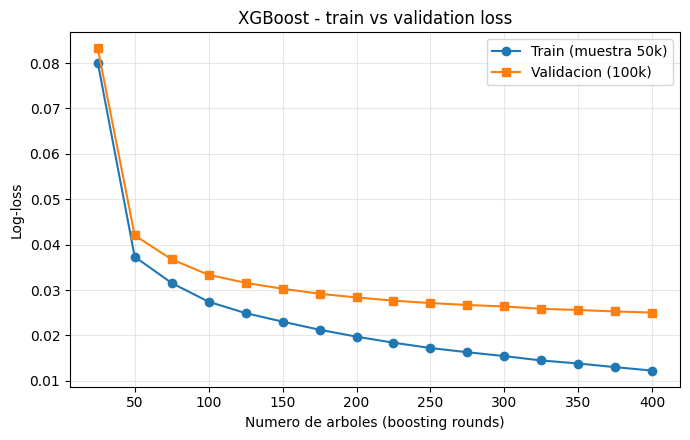


Gap train vs validacion (macro F1):
  Random Forest  train = 1.0000 | val = 0.9832 | gap = +0.0168
  XGBoost        train = 0.9971 | val = 0.9917 | gap = +0.0053


In [18]:
# ============================================================
# CELDA 6 - Diagnostico de overfitting: train vs validation loss
# ============================================================
from sklearn.metrics import log_loss

# Muestra del train para que el diagnostico no tarde tanto
# (el log-loss sobre 50k filas es un estimador suficiente).
rng = np.random.RandomState(RANDOM_STATE)
idx_diag = rng.choice(X_tr.shape[0], size=min(50000, X_tr.shape[0]), replace=False)
X_tr_diag, y_tr_diag = X_tr[idx_diag], y_tr[idx_diag]

grid = list(range(25, xgb.n_estimators + 1, 25))
loss_tr, loss_val = [], []
for n in grid:
    p_tr = xgb.predict_proba(X_tr_diag, iteration_range=(0, n))[:, 1]
    p_val = xgb.predict_proba(X_val, iteration_range=(0, n))[:, 1]
    loss_tr.append(log_loss(y_tr_diag, p_tr))
    loss_val.append(log_loss(y_val, p_val))
    print(f'  {n:3d} arboles | train logloss = {loss_tr[-1]:.4f} | val logloss = {loss_val[-1]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid, loss_tr, 'o-', label='Train (muestra 50k)')
ax.plot(grid, loss_val, 's-', label='Validacion (100k)')
ax.set_xlabel('Numero de arboles (boosting rounds)')
ax.set_ylabel('Log-loss')
ax.set_title('XGBoost - train vs validation loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/train_vs_val_loss.png', dpi=130, bbox_inches='tight')
plt.show()

# Gap train/val tambien para Random Forest (no tiene curva por
# iteraciones, asi que comparamos la metrica final en ambos conjuntos).
print('\nGap train vs validacion (macro F1):')
for nombre, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    f1_tr_m = f1_score(y_tr_diag, model.predict(X_tr_diag), average='macro')
    f1_val_m = f1_score(y_val, model.predict(X_val), average='macro')
    print(f'  {nombre:14s} train = {f1_tr_m:.4f} | val = {f1_val_m:.4f} | gap = {f1_tr_m - f1_val_m:+.4f}')

In [19]:
# ============================================================
# CELDA 7 - Desglose de resultados por lenguaje y generador
# ============================================================
# Aprovechamos las columnas extra del dataset para ver donde acierta
# y donde falla el mejor modelo (XGBoost) sobre la validacion.
df_val['pred_xgb'] = xgb_pred
df_val['correcto'] = (df_val['label'] == df_val['pred_xgb'])

print('Macro F1 por lenguaje (XGBoost):')
for lang, sub in df_val.groupby('language'):
    print(f"  {str(lang):12s} {f1_score(sub['label'], sub['pred_xgb'], average='macro'):.4f}  (n={len(sub)})")

print('\nAcierto por generador (fraccion bien clasificada):')
acierto = df_val.groupby('generator')['correcto'].mean()
conteo = df_val.groupby('generator')['correcto'].size()
for gen in acierto.sort_values().index:
    print(f'  {str(gen):25s} {acierto[gen]:.4f}  (n={conteo[gen]})')

Macro F1 por lenguaje (XGBoost):
  C++          0.9617  (n=4679)
  Java         0.9629  (n=3860)
  Python       0.9945  (n=91461)

Acierto por generador (fraccion bien clasificada):
  ibm-granite/granite-8b-code-base-4k 0.9633  (n=1362)
  codellama/CodeLlama-34b-Instruct-hf 0.9702  (n=1544)
  ibm-granite/granite-8b-code-instruct-4k 0.9799  (n=846)
  deepseek-ai/deepseek-coder-6.7b-base 0.9818  (n=1207)
  meta-llama/Llama-3.3-70B-Instruct 0.9829  (n=1756)
  bigcode/starcoder         0.9833  (n=1857)
  meta-llama/Llama-3.1-8B   0.9837  (n=1351)
  microsoft/phi-2           0.9842  (n=1966)
  Qwen/Qwen2.5-Coder-7B     0.9846  (n=1427)
  bigcode/starcoder2-15b    0.9882  (n=1872)
  codellama/CodeLlama-7b-hf 0.9885  (n=1128)
  google/codegemma-2b       0.9892  (n=1484)
  google/codegemma-7b       0.9897  (n=1258)
  bigcode/starcoder2-7b     0.9904  (n=1350)
  meta-llama/Llama-3.2-1B   0.9921  (n=760)
  human                     0.9921  (n=47695)
  meta-llama/Llama-3.2-3B   0.9923  (n=1550)
 

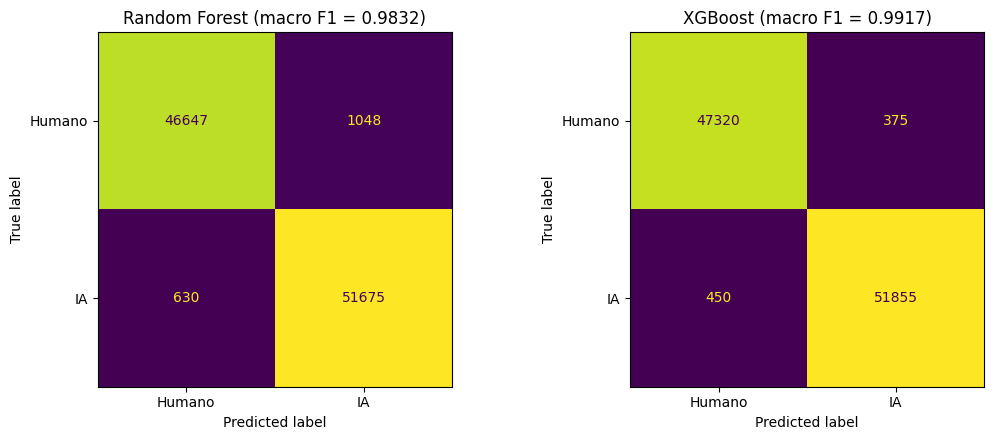

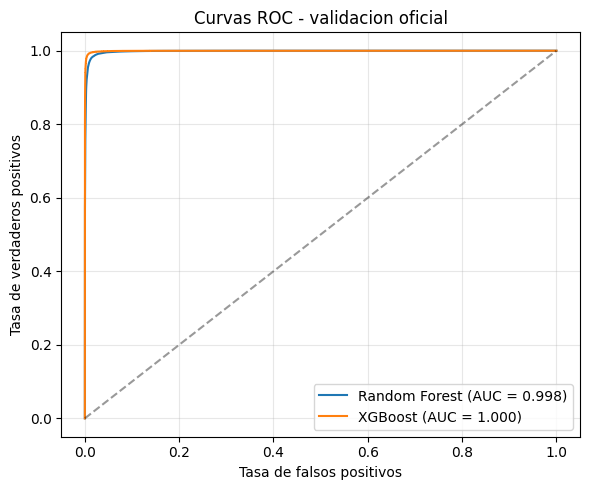

Figuras guardadas en figuras/


In [20]:
# ============================================================
# CELDA 8 - Matrices de confusion y curvas ROC (RF y XGBoost)
# ============================================================
os.makedirs('figuras', exist_ok=True)

# Matrices de confusion sobre la validacion
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nombre, pred, clave) in zip(axes, [('Random Forest', rf_pred, 'RandomForest'),
                                            ('XGBoost', xgb_pred, 'XGBoost')]):
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Humano', 'IA']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{nombre} (macro F1 = {results[clave]:.4f})')
plt.tight_layout()
plt.savefig('figuras/matrices_confusion.png', dpi=130, bbox_inches='tight')
plt.show()

# Curvas ROC de ambos modelos
fig, ax = plt.subplots(figsize=(6, 5))
for nombre, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    probs = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC - validacion oficial')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/curvas_roc.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figuras guardadas en figuras/')

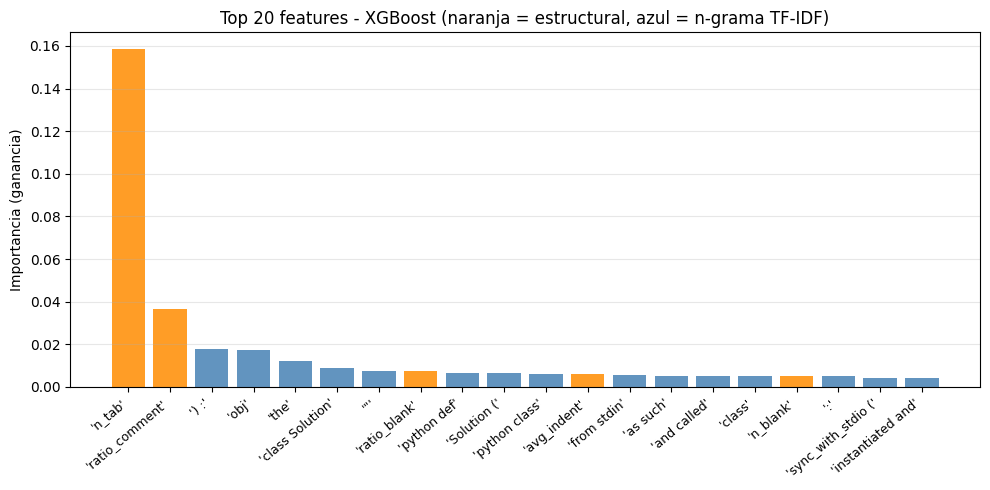

Top 10 features mas importantes:
  'n_tab'                             0.1584  (estructural)
  'ratio_comment'                     0.0365  (estructural)
  ') :'                               0.0178  (tf-idf)
  'obj'                               0.0171  (tf-idf)
  'the'                               0.0120  (tf-idf)
  'class Solution'                    0.0088  (tf-idf)
  '"'                                 0.0076  (tf-idf)
  'ratio_blank'                       0.0073  (estructural)
  'python def'                        0.0066  (tf-idf)
  'Solution ('                        0.0063  (tf-idf)


In [21]:
# ============================================================
# CELDA 9 - Importancia de features (XGBoost)
# ============================================================
# Las primeras 11 columnas de la matriz son las features estructurales
# y el resto son los n-gramas del TF-IDF; con esto vemos en que se
# fija el modelo para decidir humano vs IA.
nombres = FEATURE_NAMES + list(tfidf.get_feature_names_out())
importancias = xgb.feature_importances_
top = np.argsort(importancias)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['darkorange' if i < len(FEATURE_NAMES) else 'steelblue' for i in top]
ax.bar(range(len(top)), importancias[top], color=colores, alpha=0.85)
ax.set_xticks(range(len(top)))
ax.set_xticklabels([repr(nombres[i]) for i in top], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Importancia (ganancia)')
ax.set_title('Top 20 features - XGBoost (naranja = estructural, azul = n-grama TF-IDF)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/importancia_features.png', dpi=130, bbox_inches='tight')
plt.show()

print('Top 10 features mas importantes:')
for i in top[:10]:
    tipo = 'estructural' if i < len(FEATURE_NAMES) else 'tf-idf'
    print(f'  {nombres[i]!r:35s} {importancias[i]:.4f}  ({tipo})')

## Persistencia — usar el modelo sin reentrenar

**Para probar el modelo sin entrenar nada** (p. ej. recién clonado el repo): corre la CELDA 1 (imports), luego CARGAR (11), predict_code (14) y PRUEBAS (15). El modelo XGBoost ya entrenado viene en el repo (`modelo_reto.joblib`, ~1 MB).

**Para probar también con Random Forest:** corre además la CELDA 11b, que descarga el RF ya entrenado (~376 MB) desde el Release del repo — solo la primera vez.

**Para reentrenar desde cero:** corre todo el notebook (requiere credenciales de Kaggle, ~1 hr); la celda GUARDAR (10) regenera `modelo_reto.joblib` (versionado en git) y `artefactos_reto/` (solo local, ~380 MB).

(El flujo completo está documentado en `Marco de referencia.md`.)

In [ ]:
# ============================================================
# CELDA 10 - GUARDAR modelos entrenados (evita reentrenar)
# ============================================================
import joblib

# Bundle ligero (~1 MB) solo con XGBoost + preprocesadores: este SI se
# versiona en git, para que cualquiera del equipo pueda probar el modelo
# sin reentrenar (ver celda CARGAR).
joblib.dump(
    {'xgb': xgb, 'tfidf': tfidf, 'scaler': scaler, 'results': results},
    'modelo_reto.joblib', compress=3)
print('Bundle ligero guardado: modelo_reto.joblib '
      f'({os.path.getsize("modelo_reto.joblib")/1e6:.1f} MB)')

# Bundle completo (incluye el Random Forest, ~380 MB): solo local,
# excluido de git porque GitHub rechaza archivos > 100 MB.
ARTIFACTS_DIR = 'artefactos_reto'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
joblib.dump(
    {'rf': rf, 'xgb': xgb,
     'tfidf': tfidf, 'scaler': scaler, 'results': results},
    os.path.join(ARTIFACTS_DIR, 'modelos_entrenados.joblib'),
    compress=3)

print('Artefactos guardados en:', os.path.abspath(ARTIFACTS_DIR))
for f in sorted(os.listdir(ARTIFACTS_DIR)):
    ruta = os.path.join(ARTIFACTS_DIR, f)
    print(f'  {f:30s} {os.path.getsize(ruta)/1e6:8.2f} MB')

In [ ]:
# ============================================================
# CELDA 11 - CARGAR el modelo ya entrenado (sin reentrenar)
# ============================================================
# Ejecuta esta celda despues de la CELDA 1 (imports). Con esto puedes
# saltarte las celdas 2 a 9 e ir directo a la celda de PRUEBAS (15).
# - modelo_reto.joblib (viene en el repo, ~1 MB): XGBoost + TF-IDF +
#   scaler. Es lo unico necesario para probar el modelo.
# - artefactos_reto/ (solo local, ~380 MB): incluye ademas el Random
#   Forest; se usa de preferencia si existe.
import joblib

rf = None
FULL_PATH = os.path.join('artefactos_reto', 'modelos_entrenados.joblib')
LIGHT_PATH = 'modelo_reto.joblib'

if os.path.exists(FULL_PATH):
    bundle = joblib.load(FULL_PATH)
    rf = bundle.get('rf')
    print('Bundle completo cargado (local):', FULL_PATH)
elif os.path.exists(LIGHT_PATH):
    bundle = joblib.load(LIGHT_PATH)
    print('Bundle ligero cargado (del repo):', LIGHT_PATH)
else:
    raise FileNotFoundError(
        'No se encontro modelo_reto.joblib ni artefactos_reto/. '
        'Corre el notebook completo y la celda GUARDAR (10).')

xgb     = bundle['xgb']
tfidf   = bundle['tfidf']
scaler  = bundle['scaler']
results = bundle['results']
# Bundles de versiones anteriores traen la entrada de la extension
# CodeBERT (ya eliminada del notebook); se descarta.
results.pop('CodeBERT+RF (extension)', None)

# code_features hace falta para predict_code (CELDA 14); se redefine aqui
# para no depender de la CELDA 4 (es identica a la de esa celda).
def code_features(src):
    lines = src.split('\n')
    n_lines = len(lines)
    n_chars = len(src)
    n_blank = sum(1 for ln in lines if ln.strip() == '')
    n_comment = sum(1 for ln in lines if ln.strip().startswith(('#', '//', '/*', '*')))
    indents = [len(ln) - len(ln.lstrip(' ')) for ln in lines if ln.strip()]
    avg_indent = (sum(indents) / len(indents)) if indents else 0.0
    avg_line_len = (sum(len(ln) for ln in lines) / n_lines) if n_lines else 0.0
    n_space = src.count(' ')
    n_tab = src.count('\t')
    ratio_ws = ((n_space + n_tab) / n_chars) if n_chars else 0.0
    ratio_comment = (n_comment / n_lines) if n_lines else 0.0
    ratio_blank = (n_blank / n_lines) if n_lines else 0.0
    return [n_lines, n_chars, n_blank, n_comment, avg_indent, avg_line_len, n_space, n_tab, ratio_ws, ratio_comment, ratio_blank]

print('Modelos cargados (sin reentrenar):')
for k, v in results.items():
    print(f'  {k:30s} macro F1 = {v:.4f}')

In [ ]:
# ============================================================
# CELDA 11b - (Opcional) Descargar el Random Forest ya entrenado
# ============================================================
# El RF pesa ~376 MB, demasiado para versionarse en el repo (GitHub
# rechaza archivos > 100 MB), asi que vive como asset del Release
# "modelos-v1". Esta celda lo descarga UNA vez (sin entrenar nada) y
# lo deja en artefactos_reto/ para que la celda de PRUEBAS use los
# dos modelos. Si solo quieres XGBoost, puedes saltartela.

RF_URL = ('https://github.com/M4u2002/Reto-Compiladores-Plagio-/'
          'releases/download/modelos-v1/modelo_rf.joblib')
RF_LOCAL = os.path.join('artefactos_reto', 'modelo_rf.joblib')

if rf is not None:
    print('Random Forest ya cargado (artefactos locales).')
else:
    if not os.path.exists(RF_LOCAL):
        print('Descargando Random Forest (~376 MB, puede tardar)...')
        import urllib.request
        os.makedirs('artefactos_reto', exist_ok=True)
        urllib.request.urlretrieve(RF_URL, RF_LOCAL)
        print('Descarga completa.')
    rf = joblib.load(RF_LOCAL)['rf']
    print('Random Forest cargado desde', RF_LOCAL)

## Evaluación comparativa

Resultados sobre el **conjunto de validación oficial** de SemEval Subtask A, con la métrica oficial **macro F1**. (El análisis de resultados completo está en `Marco de referencia.md`.)

In [24]:
# ============================================================
# CELDA 12 - Tabla comparativa de modelos (macro F1)
# ============================================================
tabla = pd.DataFrame(
    [(k, v) for k, v in results.items()],
    columns=['Modelo', 'macro_F1']
).sort_values('macro_F1', ascending=False).reset_index(drop=True)
print('Comparativa de modelos (metrica oficial: macro F1)')
print(tabla.to_string(index=False))

mejor = tabla.iloc[0]
print(f"\nMejor modelo: {mejor['Modelo']}  (macro F1 = {mejor['macro_F1']:.4f})")
tabla

Comparativa de modelos (metrica oficial: macro F1)
      Modelo  macro_F1
     XGBoost  0.991733
RandomForest  0.983177

Mejor modelo: XGBoost  (macro F1 = 0.9917)


,Modelo,macro_F1
0,XGBoost,0.991733
1,RandomForest,0.983177


In [25]:
# ============================================================
# CELDA 13 - Resumen final
# ============================================================
print('=' * 55)
print('  RESUMEN - Deteccion de codigo generado por IA')
print('  Dataset: SemEval-2026 Task 13, Subtask A')
print('  Metrica oficial: macro F1')
print('=' * 55)
for nombre, f1v in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f'  {nombre:30s} {f1v:.4f}')
print('=' * 55)
print('Enfoque (replicacion del paper): Random Forest / XGBoost')
print('sobre features estructurales + TF-IDF.')

  RESUMEN - Deteccion de codigo generado por IA
  Dataset: SemEval-2026 Task 13, Subtask A
  Metrica oficial: macro F1
  XGBoost                        0.9917
  RandomForest                   0.9832
Enfoque (replicacion del paper): Random Forest / XGBoost
sobre features estructurales + TF-IDF.


In [ ]:
# ============================================================
# CELDA 14 - Funcion de prediccion sobre codigo nuevo
# ============================================================
# Usa XGBoost (el mejor modelo) y devuelve tambien la probabilidad,
# porque no es lo mismo un 51% que un 99% de confianza.
# Ojo: en fragmentos muy cortos hay poca senal estilometrica, asi que
# la prediccion puede fallar (lo discutimos en el marco de referencia).
def predict_code(src, model=None):
    model = model if model is not None else xgb
    feats = scaler.transform(np.array([code_features(src)], dtype='float32'))
    tf = tfidf.transform([src])
    x = hstack([csr_matrix(feats), tf]).tocsr()
    prob_ia = float(model.predict_proba(x)[0, 1])
    pred = int(prob_ia >= 0.5)
    etiqueta = 'MAQUINA (generado por IA)' if pred == 1 else 'HUMANO'
    return pred, etiqueta, prob_ia

print('Funcion predict_code lista.')

In [ ]:
# ============================================================
# CELDA 15 - PRUEBAS: clasifica tus propios fragmentos
# ============================================================
# Para correr esta celda NO hace falta entrenar nada: basta con la
# CELDA 1 (imports), la CELDA 11 (CARGAR) y la CELDA 14 (predict_code).
# Si el Random Forest esta disponible (artefactos locales o celda 11b),
# cada fragmento se prueba con LOS DOS modelos; si no, solo con XGBoost.
# Pega tu codigo en el diccionario `pruebas` y ejecuta.

modelos = {'XGBoost': xgb}
if rf is not None:
    modelos['Random Forest'] = rf
else:
    print('(Random Forest no disponible: solo se probara con XGBoost)\n')

pruebas = {
    'estilo humano (script directo)': '''n=int(input())
s=0
for i in range(n):
  x=int(input())
  if x%2==0: s+=x
print(s)
''',

    'estilo IA (limpio y comentado)': '''def sum_even_numbers(numbers):
    """Return the sum of all even numbers in the list."""
    # Initialize the accumulator
    total = 0
    for number in numbers:
        # Check if the number is even
        if number % 2 == 0:
            total += number
    return total

if __name__ == "__main__":
    values = [int(x) for x in input().split()]
    print(sum_even_numbers(values))
''',
}

print(f'{"Fragmento":35s} {"Modelo":15s} {"Prediccion":28s} {"Prob. IA"}')
print('-' * 90)
for nombre, codigo in pruebas.items():
    for mod_nombre, mod in modelos.items():
        pred, etiqueta, prob_ia = predict_code(codigo, model=mod)
        print(f'{nombre:35s} {mod_nombre:15s} {etiqueta:28s} {prob_ia:.2%}')
    print()

print('Para probar con tu propio codigo, agrega una entrada a `pruebas`')
print('o llama directo: predict_code(open("archivo.py", encoding="utf-8").read())')